# Gene Expression Pattern Matching Analysis

Extending Ethan Kyi's NMF-based gene expression analysis with Pearson correlation, DTW, and cosine similarity to evaluate which metrics best capture biologically meaningful patterns.

**NMF Audit (Phase 1A):** NMF decomposes the expression matrix into non-negative factors, so it **cannot represent the direction of regulation** (up vs. down). A gene upregulated 2x and one downregulated 2x get similar coefficient magnitudes. The similarity metrics below preserve direction information.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats as scipy_stats
from scipy.spatial.distance import cosine as cosine_distance
from dtw import dtw as dtw_func
from matplotlib.lines import Line2D

%matplotlib inline

## Phase 1: Load data, extract NMF results, normalize

In [4]:
# File paths (relative to project root)
results = "analysis data/NMF run results/clusters"
resultsLT = "analysis data/NMF run results/clustersLT"
genes_csv = "analysis data/gene_list.csv"

genes = pd.read_csv(genes_csv, header=None).squeeze().tolist()

# Ethan's NMF coefficient extraction
def extract_coeff(folder):
    cluster_dfs = {}
    for filename in sorted(os.listdir(folder)):
        path = os.path.join(folder, filename)
        rows = []
        with open(path) as file:
            for line in file:
                if line.startswith("row-"):
                    values = [float(x) for x in line[4:].strip().split(",")[1:4]]
                    rows.append(values)
        num_patterns = len(rows[0]) if rows else 0
        pattern_cols = [f"pattern{i+1}" for i in range(num_patterns)]
        cluster_name = os.path.splitext(filename)[0].split('_')[0]
        cluster_dfs[cluster_name] = pd.DataFrame(rows, columns=pattern_cols, index=genes)
        cluster_dfs[cluster_name].index.name = "gene"
    return cluster_dfs

# Ethan's pattern extraction
def extract_patterns(folder):
    patterns_df = {}
    for filename in sorted(os.listdir(folder)):
        path = os.path.join(folder, filename)
        cluster_name = os.path.splitext(filename)[0].split('_')[0]
        if cluster_name not in patterns_df:
            patterns_df[cluster_name] = {}
        with open(path) as file:
            for line in file:
                if line.startswith('#"'):
                    parts = line.strip().split(',')
                    parts = parts[1].split()
                    vals = [float(x) for x in parts]
                    pattern_key = f"pattern{len(patterns_df[cluster_name]) + 1}"
                    patterns_df[cluster_name][pattern_key] = vals
    return patterns_df

def top_genes_per_pattern(cluster_df, n=20):
    top_ranked_genes = {}
    for cluster_name, df in cluster_df.items():
        top_ranked_genes[cluster_name] = {}
        for pattern in df.columns:
            top_ranked_genes[cluster_name][pattern] = df[pattern].sort_values(ascending=False).head(n)
    return top_ranked_genes

cluster_dfs = extract_coeff(results)
clusterLT_dfs = extract_coeff(resultsLT)
patterns = extract_patterns(results)
patternsLT = extract_patterns(resultsLT)
top_genes = top_genes_per_pattern(cluster_dfs)
top_genesLT = top_genes_per_pattern(clusterLT_dfs)

# Constraint patterns — the actual biological patterns observed in each cluster
constraints = {
    "clusterOne": [1.45, 12.0, 5.21, 6.51],
    "clusterTwo": [0.371, 0.803, 1.22, 1.78],
    "clusterThree": [0.0405, 0, 0.0369, 0.0353],
    "clusterFour": [0.00913, 0.638, 0.0178, 0.0243]
}
constraintsLT = {
    "clusterOneLT": [.894475, 2.568650, 1.826, 2.016452],
    "clusterTwoLT": [0.036407, 0.589570, 0.798347, 1.023510],
    "clusterThreeLT": [0.039660, 0.0, 0.036266, 0.034714],
    "clusterFourLT": [0.009090, 0.493705, 0.017601, 0.024007]
}

# Wrap constraints into {cluster: {pattern_name: values}} format
constraint_patterns = {k: {"constraint": v} for k, v in constraints.items()}
constraint_patternsLT = {k: {"constraint": v} for k, v in constraintsLT.items()}

print("NMF data loaded.")
print(f"Clusters (raw): {list(constraint_patterns.keys())}")
print(f"Clusters (LT):  {list(constraint_patternsLT.keys())}")

NMF data loaded.
Clusters (raw): ['clusterOne', 'clusterTwo', 'clusterThree', 'clusterFour']
Clusters (LT):  ['clusterOneLT', 'clusterTwoLT', 'clusterThreeLT', 'clusterFourLT']


In [5]:
# Load and normalize gene expression data
def load_gene_counts(lt=False):
    suffix = "LT" if lt else ""
    folder = f"analysis data/gene_counts{suffix}/"
    x = [0, 3, 6, 9]
    cluster_counts = {}
    for filename in sorted(os.listdir(folder)):
        if not filename.endswith(".csv"):
            continue
        path = os.path.join(folder, filename)
        df = pd.read_csv(path, index_col=0)
        df.columns = x
        cluster_name = filename.split("_")[0]
        cluster_counts[cluster_name] = df
    return cluster_counts

def normalize_01(cluster_counts):
    """Min-max normalize each gene's time series to (0, 1]."""
    eps = 1e-10
    normalized = {}
    for cluster_name, df in cluster_counts.items():
        row_min = df.min(axis=1)
        row_max = df.max(axis=1)
        row_range = row_max - row_min
        norm_df = df.sub(row_min, axis=0).add(eps).div(row_range.add(eps), axis=0)
        constant_mask = row_range == 0
        norm_df.loc[constant_mask] = 1.0
        normalized[cluster_name] = norm_df
    return normalized

gene_counts = load_gene_counts(lt=False)
gene_countsLT = load_gene_counts(lt=True)
gene_counts_norm = normalize_01(gene_counts)
gene_countsLT_norm = normalize_01(gene_countsLT)

# Validation
sample = list(gene_counts.keys())[0]
print(f"Cluster: {sample} | Shape: {gene_counts[sample].shape}")
print(f"Normalized range: ({gene_counts_norm[sample].min().min():.1e}, {gene_counts_norm[sample].max().max():.1f}]")
print(f"Total genes across all clusters: {sum(df.shape[0] for df in gene_counts.values())}")

Cluster: clusterFour | Shape: (17856, 4)
Normalized range: (5.3e-11, 1.0]
Total genes across all clusters: 71424


## Phase 2: Similarity metrics (Pearson, DTW, Cosine)

All three methods compare each gene's normalized expression time series against the **constraint pattern** for its cluster.

In [6]:
# Define similarity functions
def top_genes_pearson(patterns, gene_counts_norm, n=20):
    results = {}
    for cluster_name, cluster_patterns in patterns.items():
        df = gene_counts_norm[cluster_name]
        gene_matrix = df.values
        gene_names = df.index.tolist()
        n_genes = gene_matrix.shape[0]
        cluster_results = {}
        for pattern_name, pattern_vec in cluster_patterns.items():
            pattern_arr = np.array(pattern_vec, dtype=float)
            if np.std(pattern_arr) == 0:
                r_values = np.zeros(n_genes)
            else:
                r_values = np.empty(n_genes)
                for i in range(n_genes):
                    gene_vec = gene_matrix[i]
                    if np.std(gene_vec) == 0:
                        r_values[i] = 0.0
                    else:
                        r, _ = scipy_stats.pearsonr(pattern_arr, gene_vec)
                        r_values[i] = r if np.isfinite(r) else 0.0
            r_series = pd.Series(r_values, index=gene_names, name=pattern_name)
            cluster_results[pattern_name] = r_series.sort_values(ascending=False).head(n)
        results[cluster_name] = cluster_results
    return results

def top_genes_dtw(patterns, gene_counts_norm, n=20):
    results = {}
    eps = 1e-10
    for cluster_name, cluster_patterns in patterns.items():
        results[cluster_name] = {}
        df = gene_counts_norm[cluster_name]
        gene_matrix = df.values
        for pattern_name, pattern_vals in cluster_patterns.items():
            p = np.array(pattern_vals, dtype=float)
            p_norm = (p - p.min() + eps) / (p.max() - p.min() + eps)
            distances = np.empty(len(df), dtype=float)
            for i in range(len(df)):
                alignment = dtw_func(p_norm, gene_matrix[i].astype(float))
                distances[i] = alignment.distance
            dist_series = pd.Series(distances, index=df.index)
            results[cluster_name][pattern_name] = dist_series.nsmallest(n)
    return results

def top_genes_cosine(patterns, gene_counts_norm, n=20):
    results = {}
    for cluster_name, cluster_patterns in patterns.items():
        results[cluster_name] = {}
        df = gene_counts_norm[cluster_name]
        gene_matrix = df.values
        gene_names = df.index.tolist()
        for pattern_name, pattern_vec in cluster_patterns.items():
            pattern_arr = np.array(pattern_vec, dtype=float)
            if np.linalg.norm(pattern_arr) == 0:
                similarities = np.zeros(len(gene_names))
            else:
                similarities = np.empty(len(gene_names), dtype=float)
                for i, gene_vec in enumerate(gene_matrix):
                    if np.linalg.norm(gene_vec) == 0:
                        similarities[i] = 0.0
                    else:
                        similarities[i] = 1.0 - cosine_distance(pattern_arr, gene_vec)
            sim_series = pd.Series(similarities, index=gene_names)
            results[cluster_name][pattern_name] = sim_series.nlargest(n)
    return results

print("Similarity functions defined.")

Similarity functions defined.


In [7]:
# Run all three metrics (this takes a few minutes due to DTW)
print("Computing Pearson correlation...")
pearson_top = top_genes_pearson(constraint_patterns, gene_counts_norm, n=20)
pearson_topLT = top_genes_pearson(constraint_patternsLT, gene_countsLT_norm, n=20)

print("Computing DTW distance...")
dtw_top = top_genes_dtw(constraint_patterns, gene_counts_norm, n=20)
dtw_topLT = top_genes_dtw(constraint_patternsLT, gene_countsLT_norm, n=20)

print("Computing Cosine similarity...")
cosine_top = top_genes_cosine(constraint_patterns, gene_counts_norm, n=20)
cosine_topLT = top_genes_cosine(constraint_patternsLT, gene_countsLT_norm, n=20)

print("Done!")

Computing Pearson correlation...
Computing DTW distance...
Computing Cosine similarity...
Done!


### Phase 2 Validation: Top 10 genes comparison

In [8]:
# Compare top 10 genes across methods for first cluster
val_cluster = list(constraint_patterns.keys())[0]
print(f"Top 10 genes for {val_cluster} constraint pattern:\n")

pears_top10 = pearson_top[val_cluster]["constraint"].head(10).index.tolist()
dtw_top10 = dtw_top[val_cluster]["constraint"].head(10).index.tolist()
cos_top10 = cosine_top[val_cluster]["constraint"].head(10).index.tolist()

print(f"{'Rank':<5} {'Pearson':<20} {'DTW':<20} {'Cosine':<20}")
print("-" * 65)
for i in range(10):
    print(f"{i+1:<5} {pears_top10[i]:<20} {dtw_top10[i]:<20} {cos_top10[i]:<20}")

print(f"\nOverlap (top 10):")
methods = {"Pearson": set(pears_top10), "DTW": set(dtw_top10), "Cosine": set(cos_top10)}
for m1 in methods:
    for m2 in methods:
        if m1 < m2:
            print(f"  {m1} vs {m2}: {len(methods[m1] & methods[m2])}/10 shared")

Top 10 genes for clusterOne constraint pattern:

Rank  Pearson              DTW                  Cosine              
-----------------------------------------------------------------
1     REXO2                REXO2                EEF1A1              
2     YIF1A                SSR3                 VPS51               
3     OTUD7A               OTUD7A               YIF1B               
4     ACBD3                YIF1A                PEBP1               
5     SSR3                 ACBD3                SEPTIN2             
6     ALDH3A2              ALDH3A2              AC107959.1          
7     CDC26                ZNF512               TIMM17A             
8     ZNF512               PPIB                 ADAM10              
9     EIF2AK4              PRPF31               FAAP100             
10    GSPT2                GSPT2                MFSD14A             

Overlap (top 10):
  DTW vs Pearson: 8/10 shared
  Cosine vs Pearson: 0/10 shared
  Cosine vs DTW: 0/10 shared


## Phase 3A: Per-method plots (Raw data)

Top 20 gene expression curves overlaid with the constraint pattern for each cluster.

In [9]:
def plot_genes_per_method(method_name, method_top, patterns, gene_counts, lt=False, n=20):
    x = [0, 3, 6, 9]
    suffix = "LT" if lt else ""
    for cluster_name, pattern_dict in patterns.items():
        gene_file = f"analysis data/gene_counts{suffix}/{cluster_name}_annotated.csv"
        gene_df = pd.read_csv(gene_file, index_col=0)
        gene_df.columns = x
        for pattern_name, pattern_vals in pattern_dict.items():
            top_series = method_top[cluster_name][pattern_name].head(n)
            top_gene_names = top_series.index.tolist()
            fig, ax = plt.subplots(figsize=(10, 6))
            plotted = 0
            for gene in top_gene_names:
                if gene in gene_df.index:
                    ax.plot(x, gene_df.loc[gene], color="steelblue", alpha=0.4, linewidth=1)
                    plotted += 1
            ax.plot(x, pattern_vals, color="crimson", linewidth=2.5, linestyle="--")
            ax.set_title(f"{method_name} | {cluster_name} | Top {n} genes {'(LT)' if lt else ''}")
            ax.set_xlabel("Timepoint")
            ax.set_ylabel("Gene counts")
            ax.set_xticks(x)
            legend_elements = [
                Line2D([0], [0], color="crimson", linewidth=2.5, linestyle="--", label="Constraint pattern"),
                Line2D([0], [0], color="steelblue", alpha=0.4, label=f"Top {n} genes (n={plotted})")
            ]
            ax.legend(handles=legend_elements, loc="upper right")
            plt.tight_layout()
            plt.show()

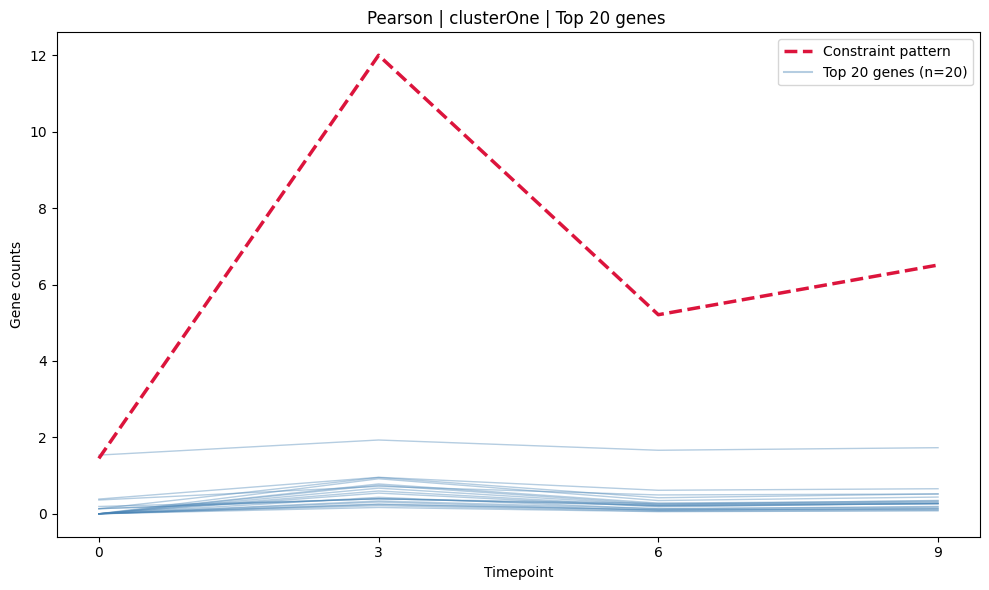

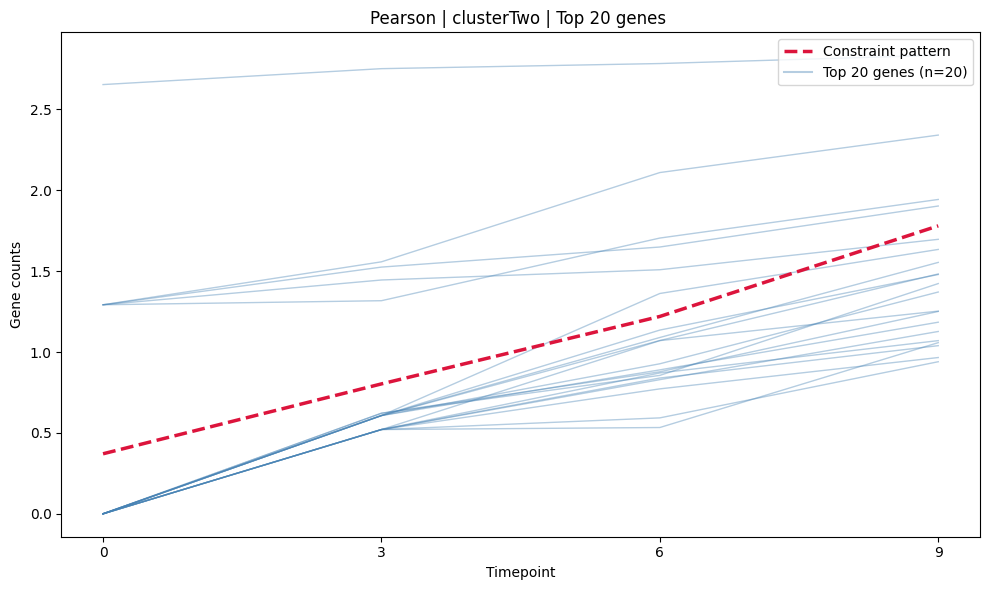

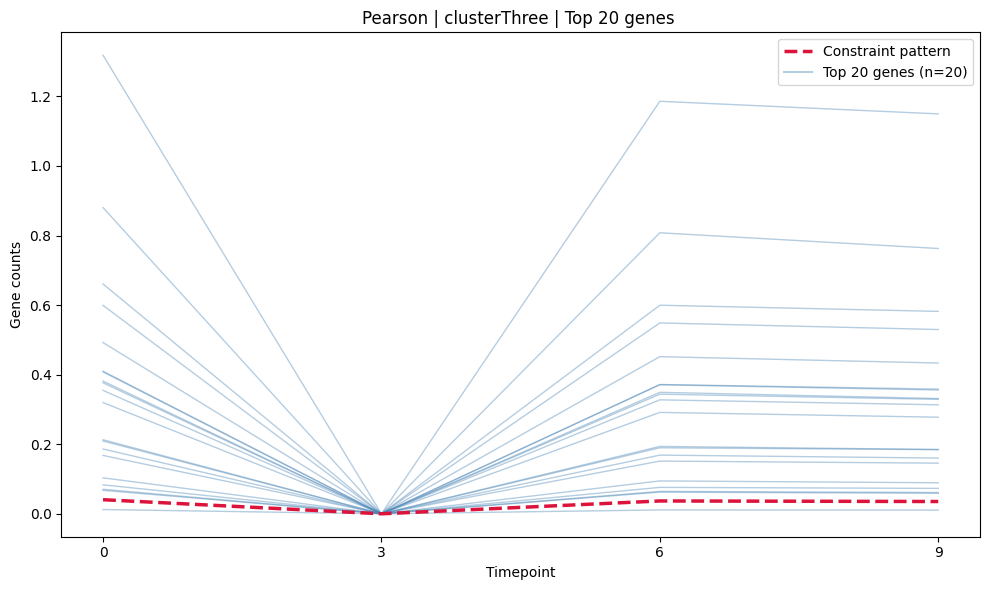

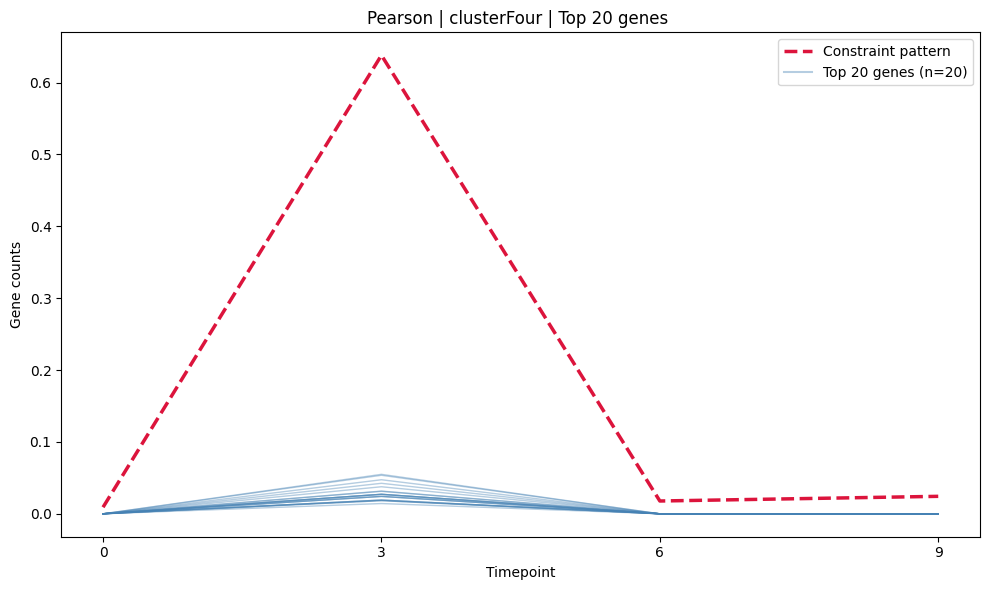

In [10]:
plot_genes_per_method("Pearson", pearson_top, constraint_patterns, gene_counts)

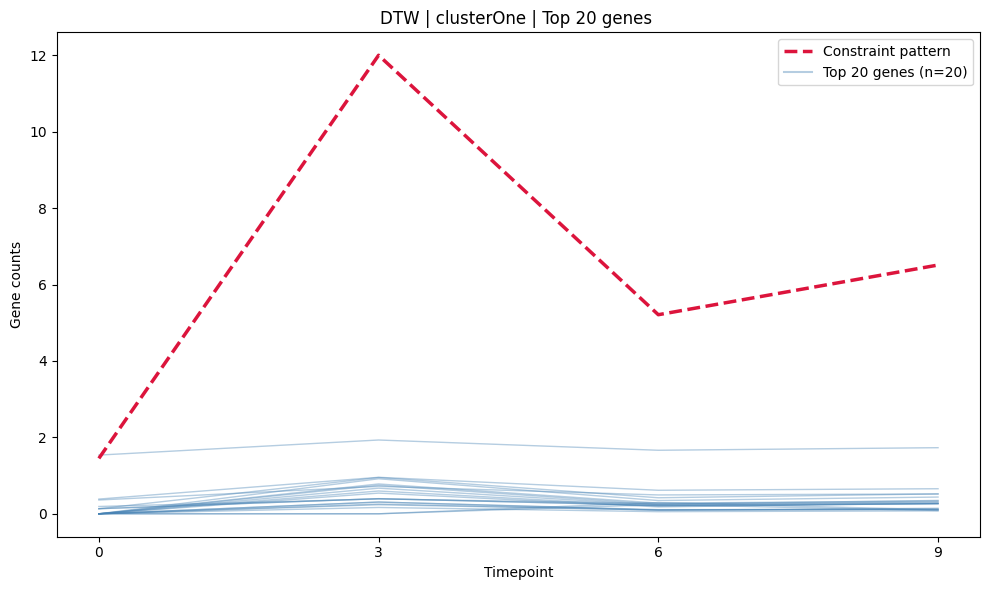

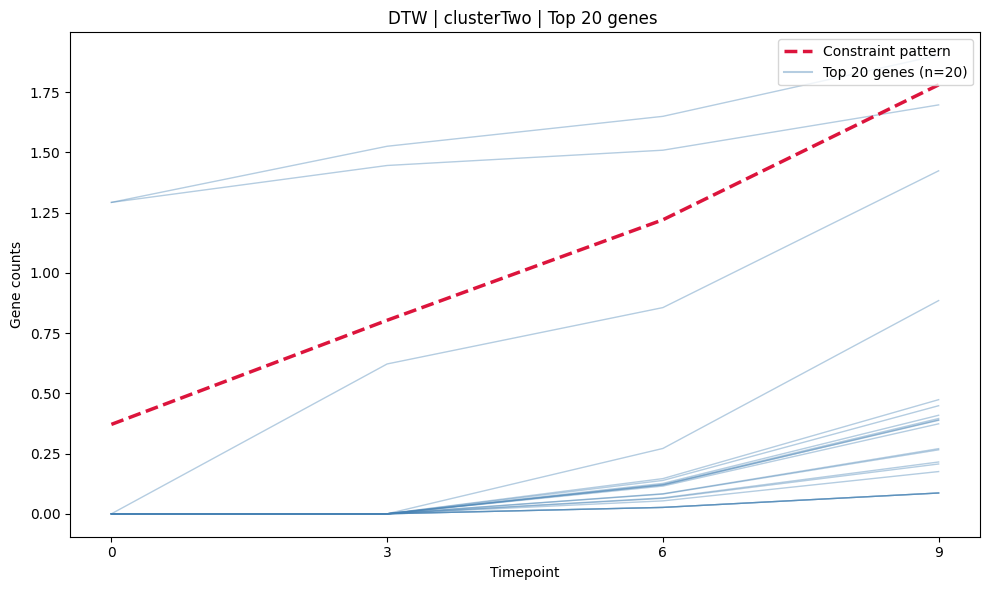

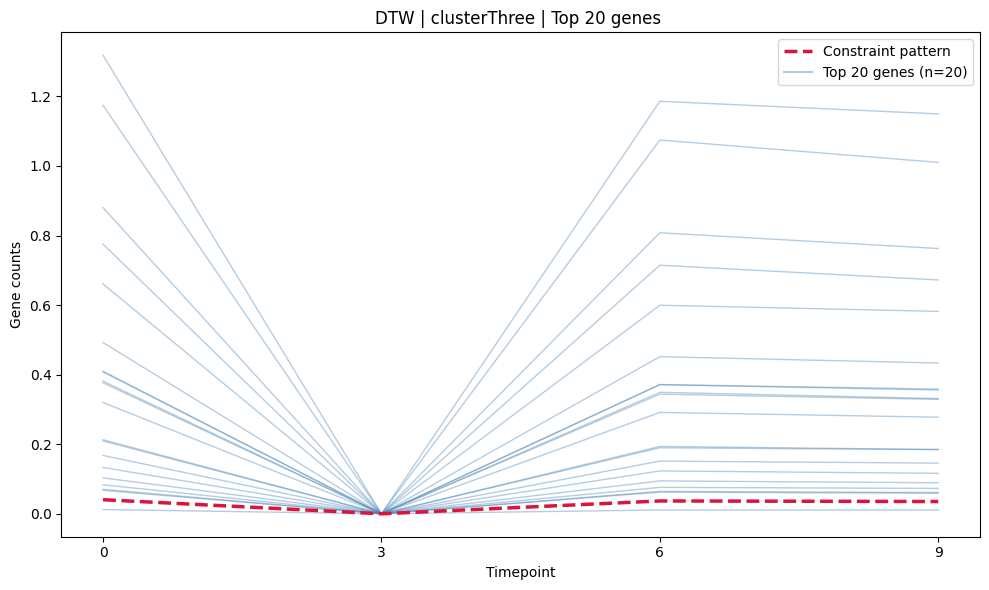

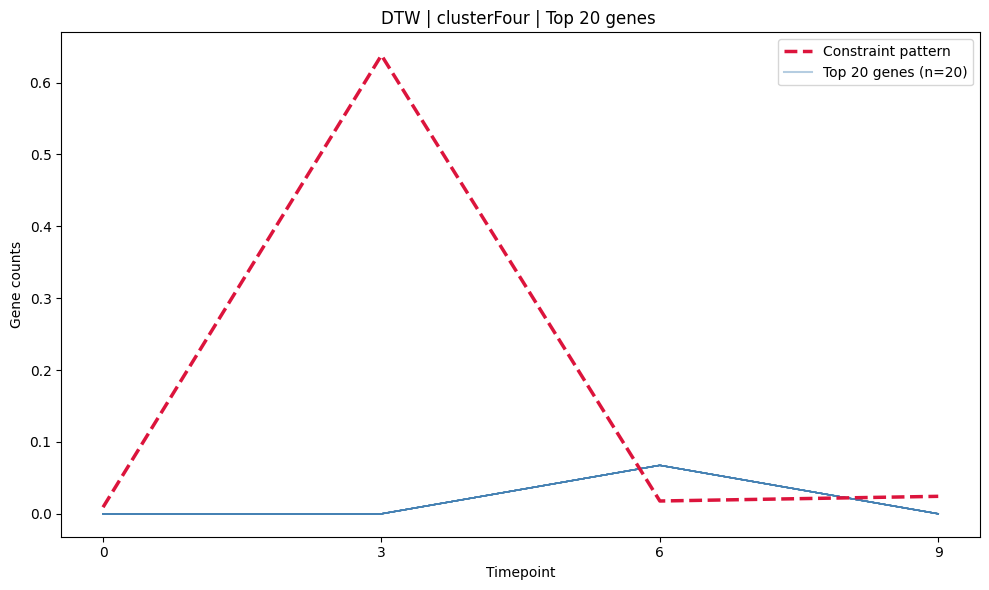

In [11]:
plot_genes_per_method("DTW", dtw_top, constraint_patterns, gene_counts)

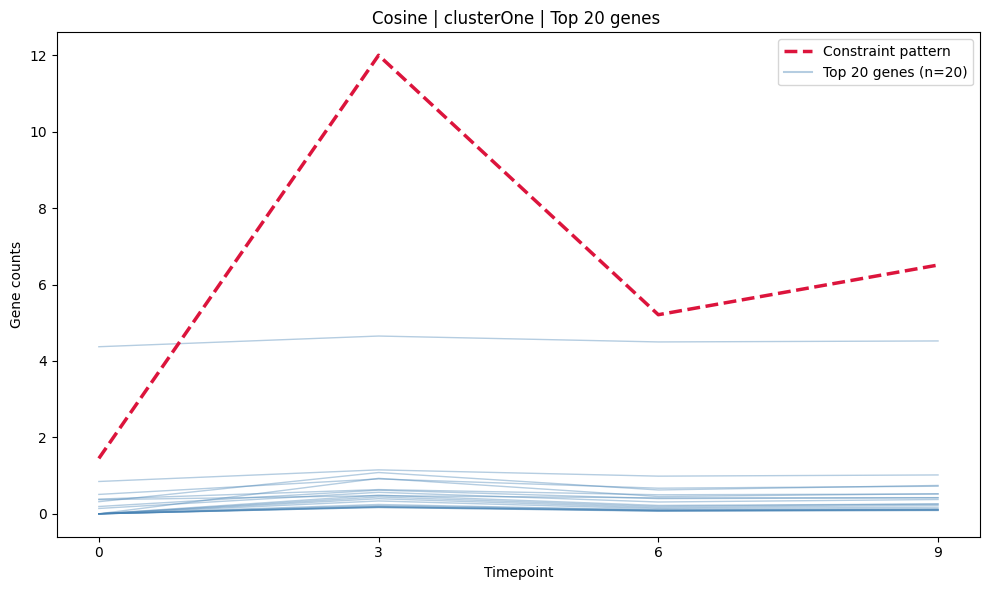

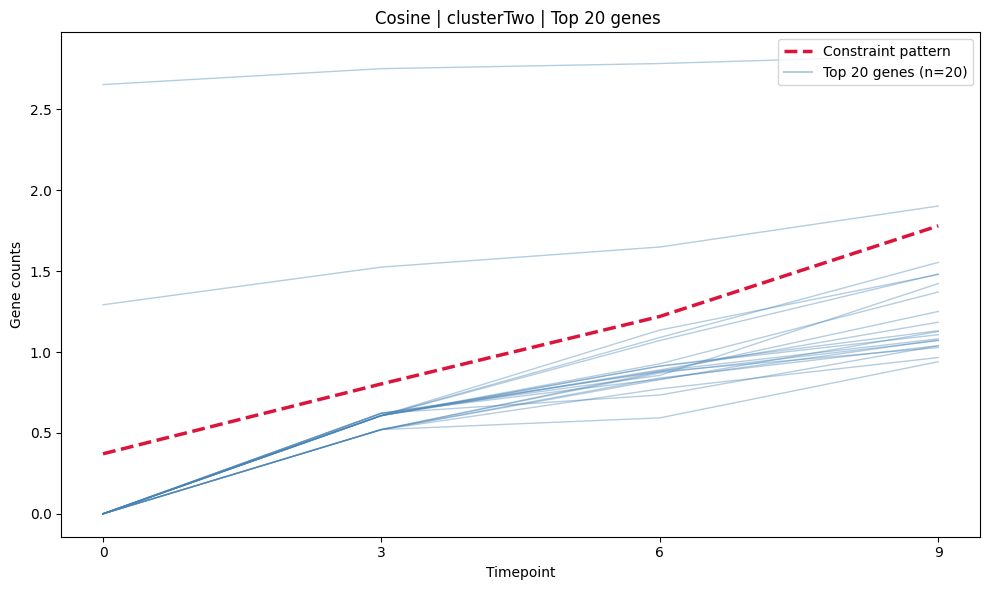

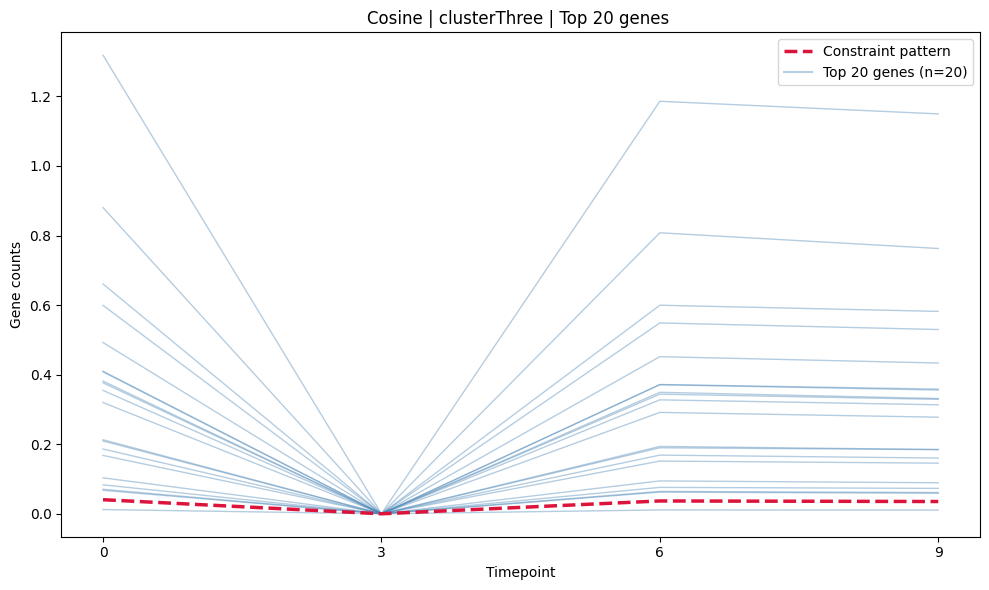

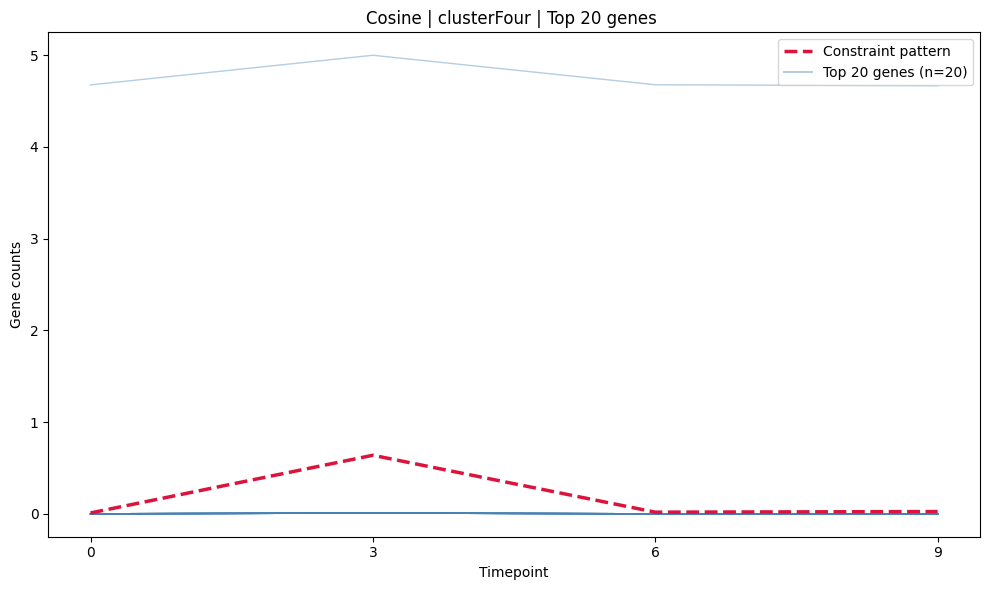

In [12]:
plot_genes_per_method("Cosine", cosine_top, constraint_patterns, gene_counts)

## Phase 3A (cont.): Per-method plots (Log-transformed data)

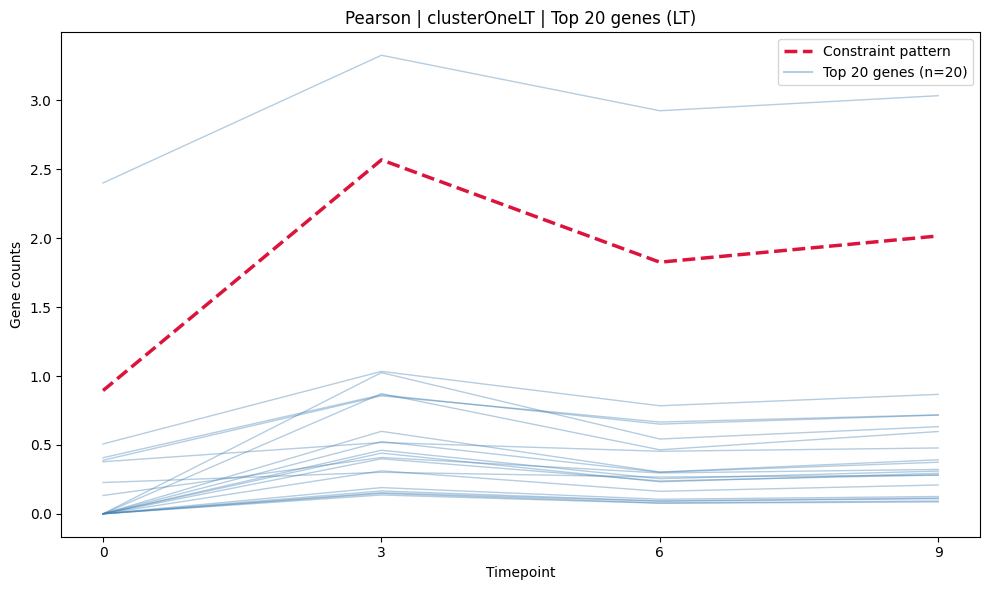

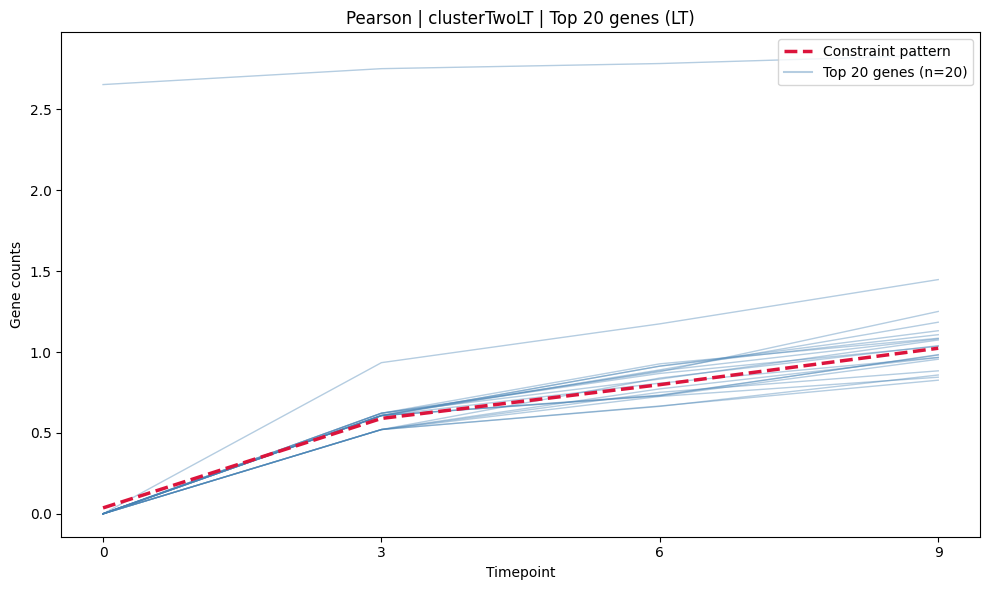

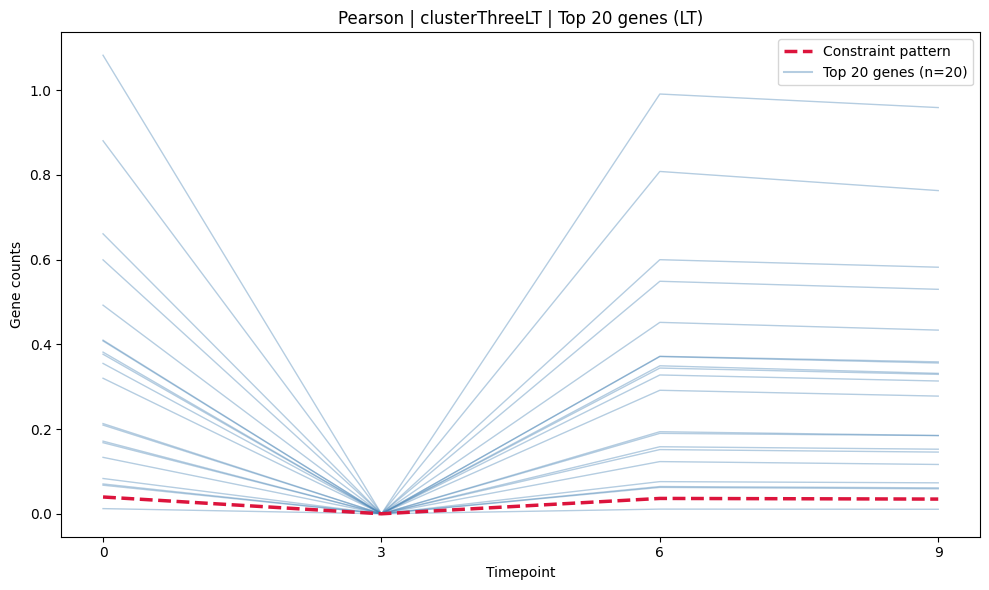

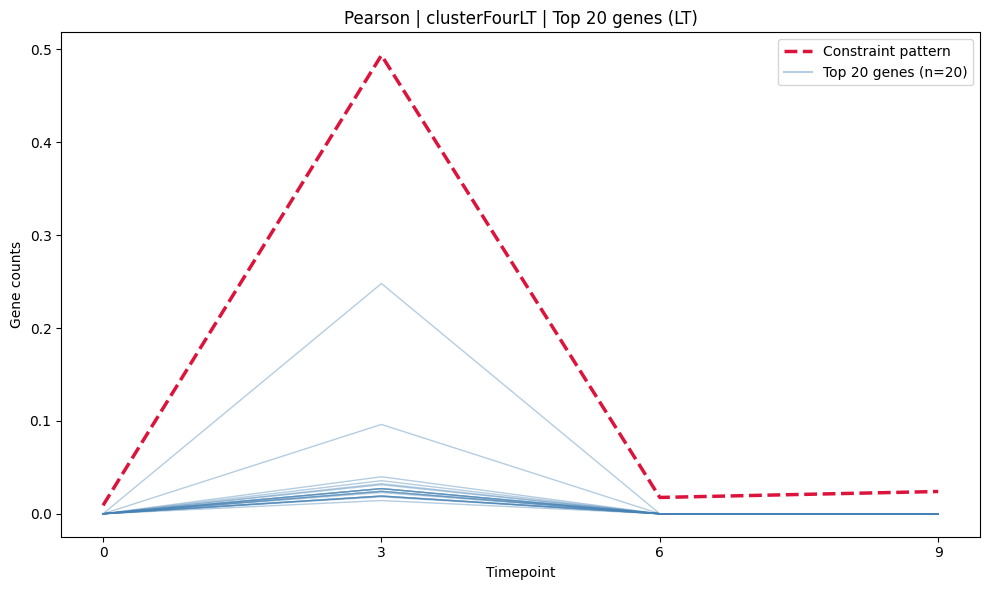

In [13]:
plot_genes_per_method("Pearson", pearson_topLT, constraint_patternsLT, gene_countsLT, lt=True)

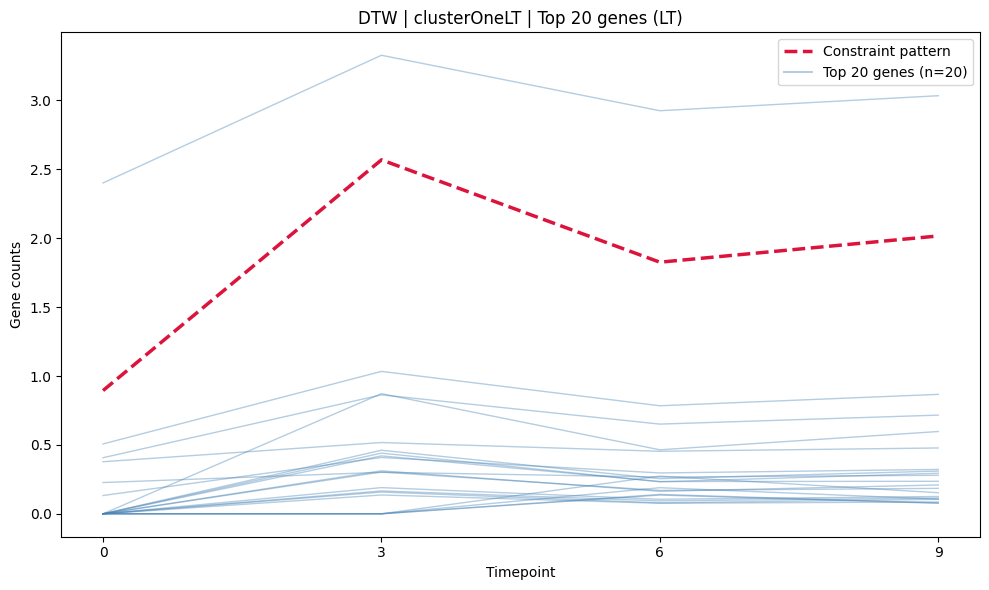

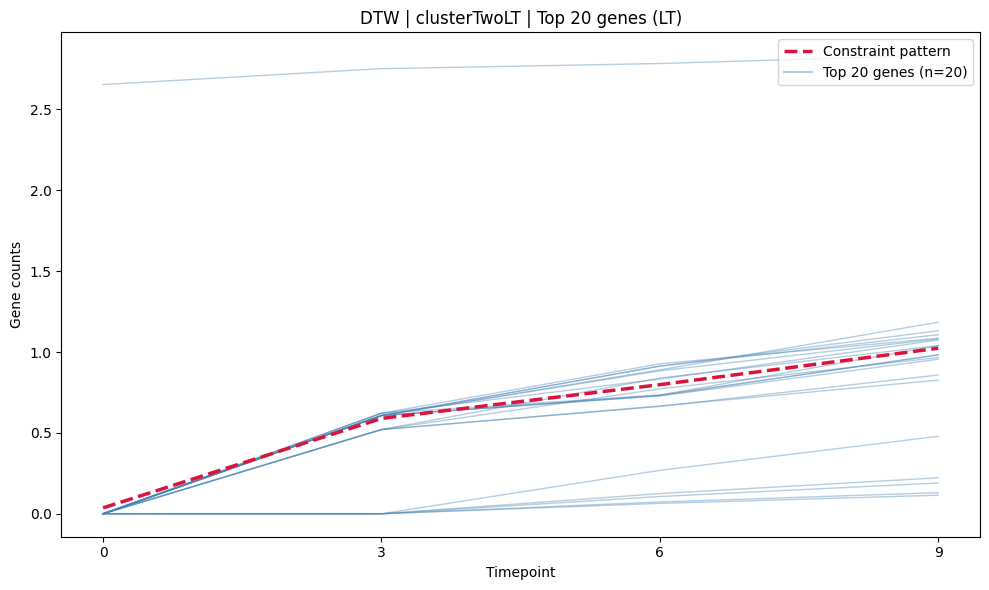

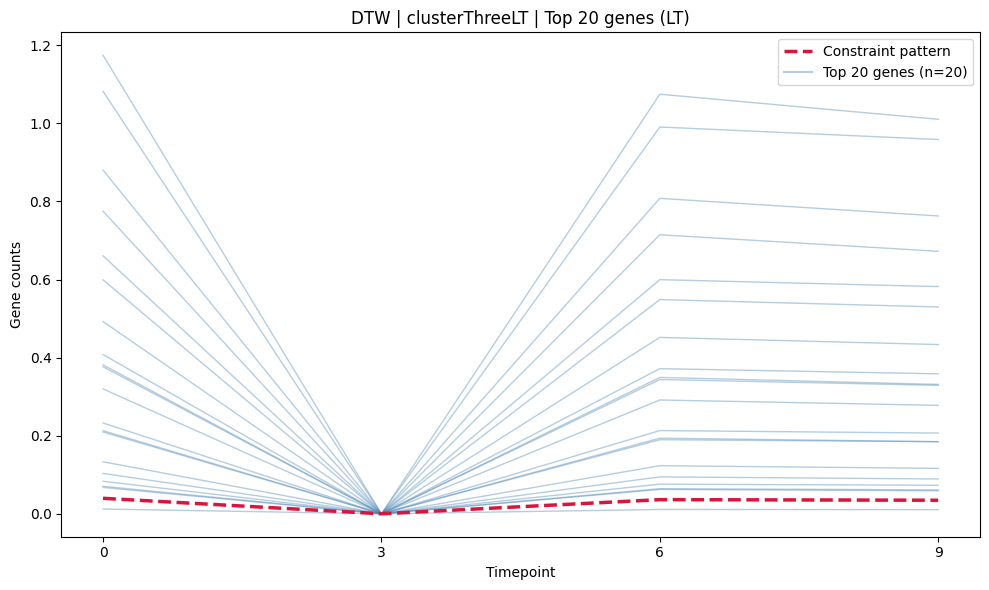

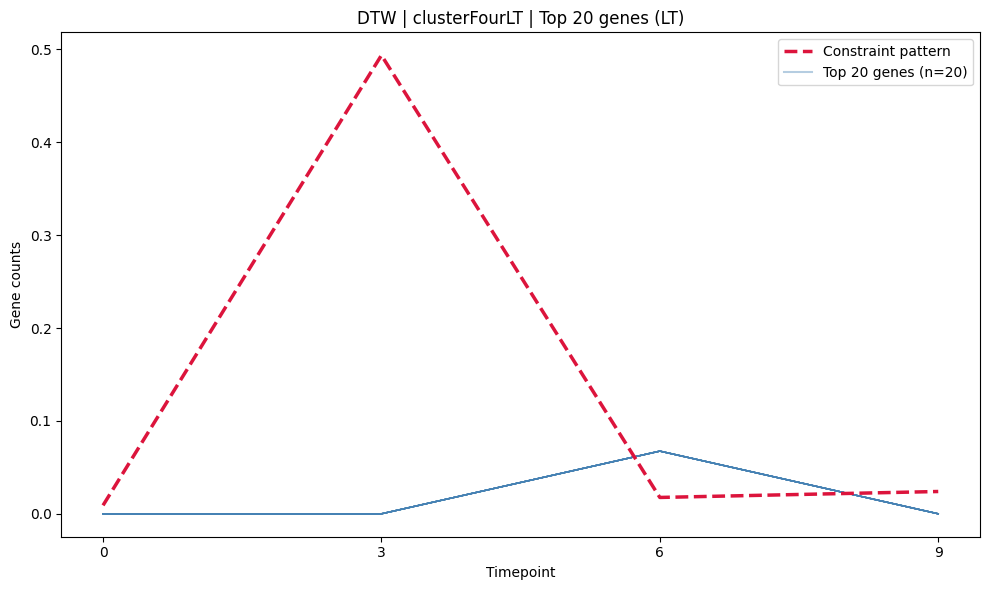

In [14]:
plot_genes_per_method("DTW", dtw_topLT, constraint_patternsLT, gene_countsLT, lt=True)

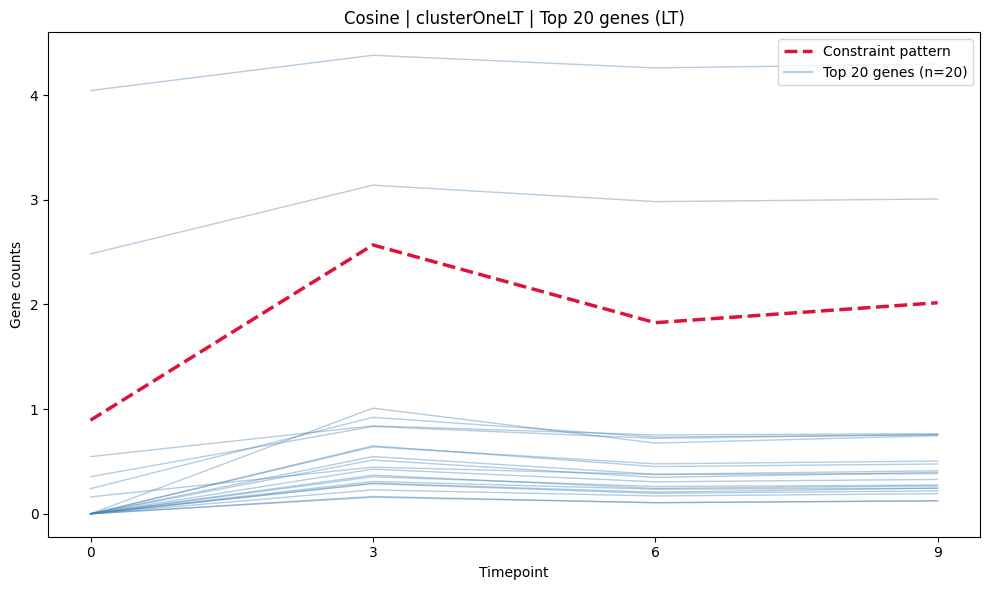

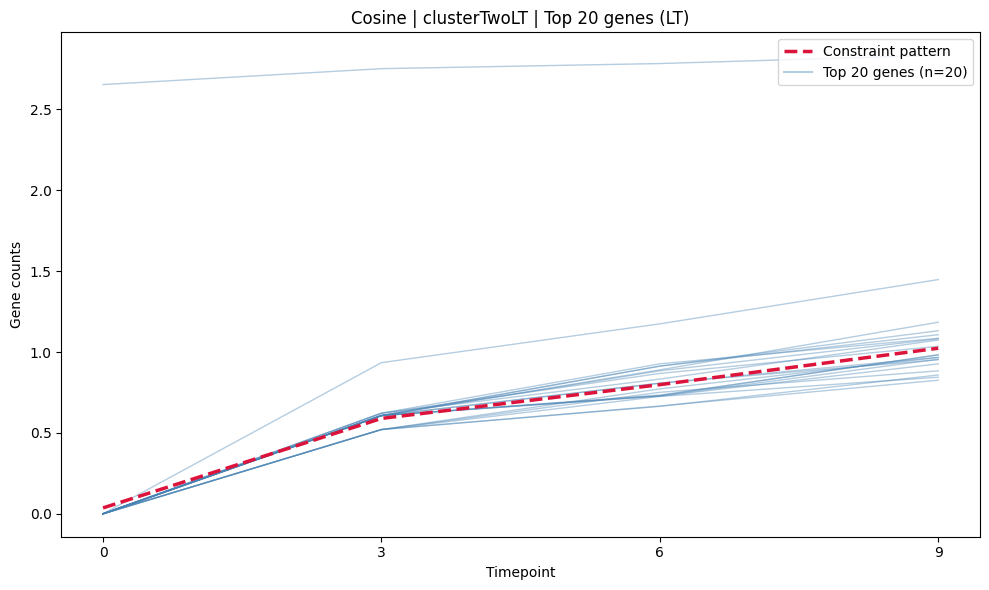

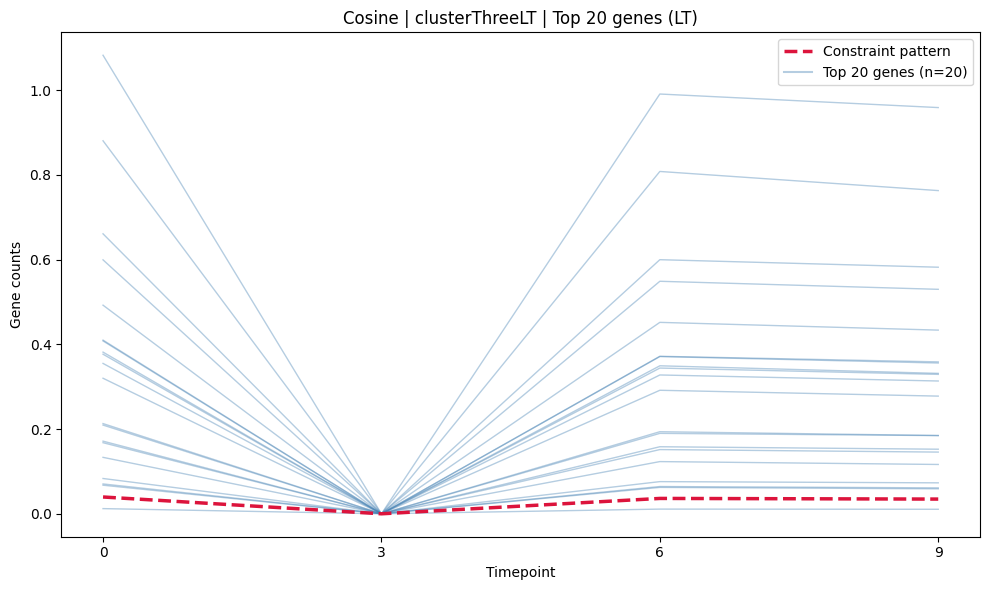

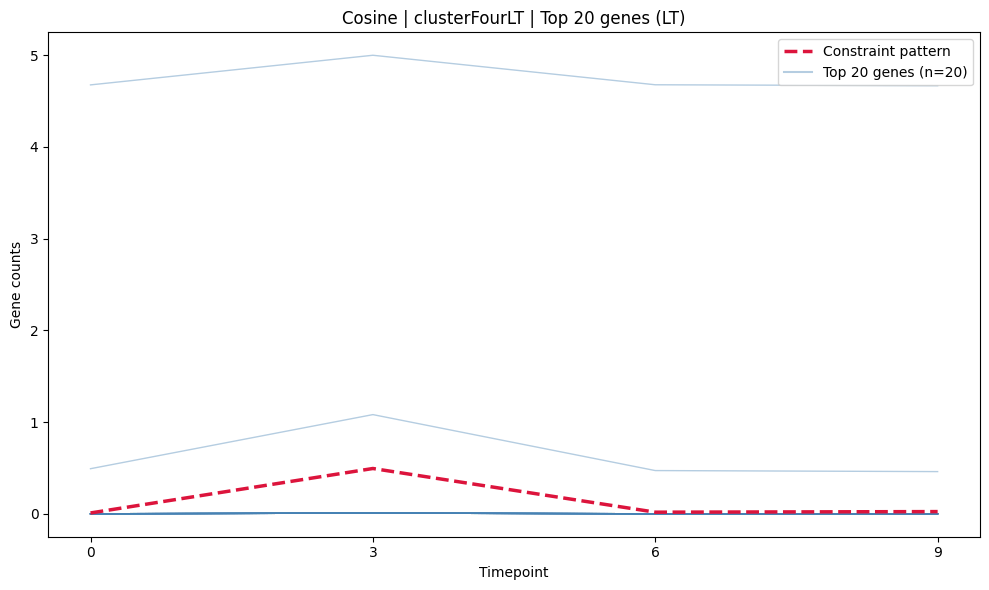

In [15]:
plot_genes_per_method("Cosine", cosine_topLT, constraint_patternsLT, gene_countsLT, lt=True)

## Phase 3B: Cross-method overlap heatmaps

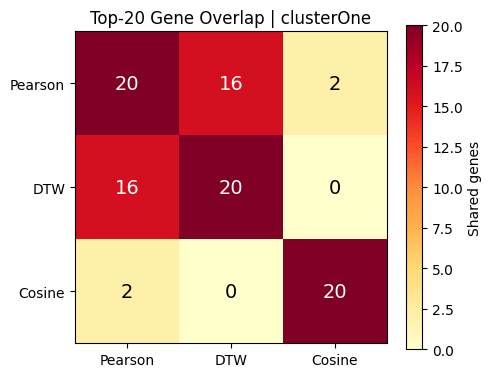

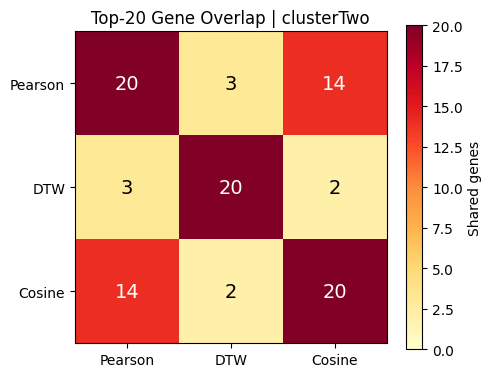

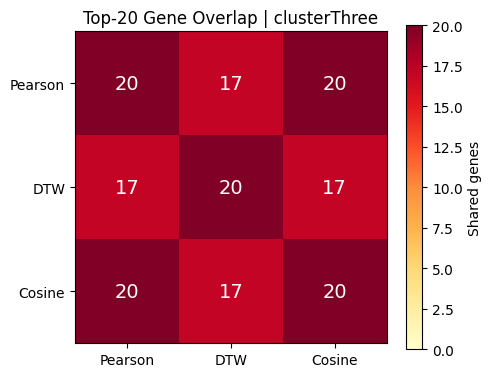

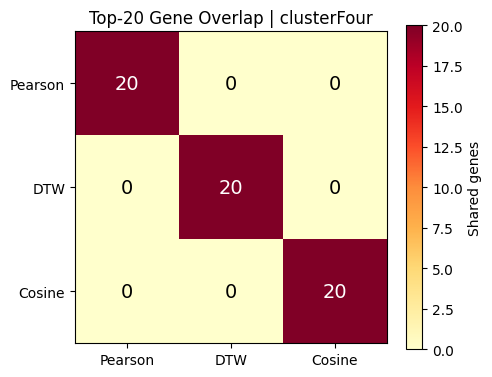

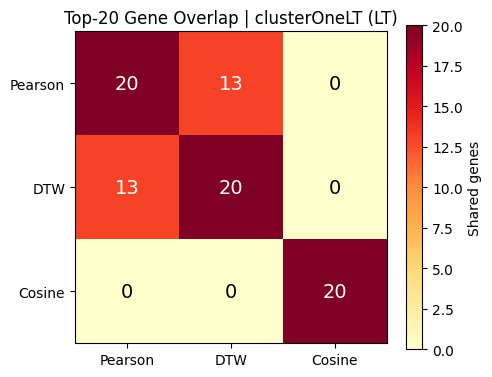

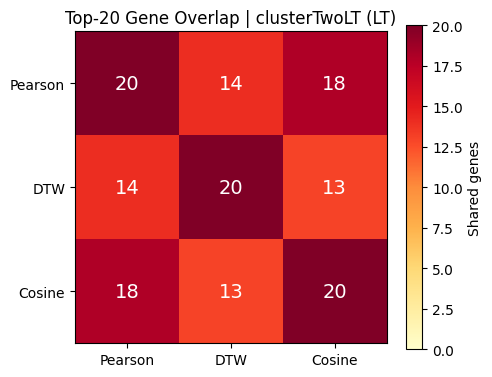

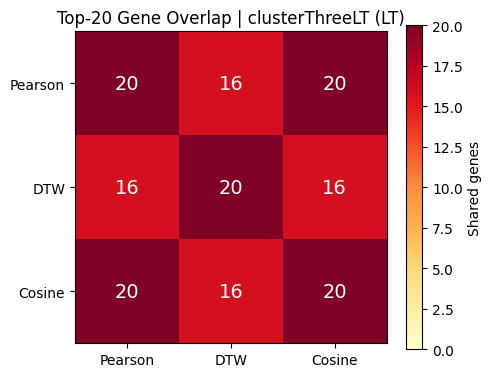

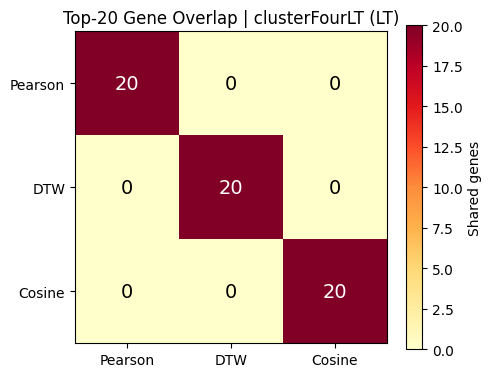

In [16]:
def plot_cross_method_heatmap(patterns, pearson_top, dtw_top, cosine_top, lt=False, n=20):
    method_names = ["Pearson", "DTW", "Cosine"]
    method_dicts = [pearson_top, dtw_top, cosine_top]
    nm = len(method_names)
    for cluster_name, pattern_dict in patterns.items():
        for pattern_name in pattern_dict:
            gene_sets = [set(md[cluster_name][pattern_name].head(n).index.tolist()) for md in method_dicts]
            overlap_matrix = np.zeros((nm, nm), dtype=int)
            for i in range(nm):
                for j in range(nm):
                    overlap_matrix[i, j] = len(gene_sets[i] & gene_sets[j])
            fig, ax = plt.subplots(figsize=(5, 4))
            im = ax.imshow(overlap_matrix, cmap="YlOrRd", vmin=0, vmax=n)
            ax.set_xticks(range(nm))
            ax.set_yticks(range(nm))
            ax.set_xticklabels(method_names)
            ax.set_yticklabels(method_names)
            ax.set_title(f"Top-{n} Gene Overlap | {cluster_name}{' (LT)' if lt else ''}")
            for i in range(nm):
                for j in range(nm):
                    ax.text(j, i, str(overlap_matrix[i, j]), ha="center", va="center",
                            fontsize=14, color="white" if overlap_matrix[i, j] > n / 2 else "black")
            plt.colorbar(im, ax=ax, label="Shared genes")
            plt.tight_layout()
            plt.show()

plot_cross_method_heatmap(constraint_patterns, pearson_top, dtw_top, cosine_top)
plot_cross_method_heatmap(constraint_patternsLT, pearson_topLT, dtw_topLT, cosine_topLT, lt=True)

## Phase 4: Final summary table

Top-20 gene overlap across all method pairs for each cluster.

In [17]:
method_pairs = [("Pearson", "DTW"), ("Pearson", "Cosine"), ("DTW", "Cosine")]

for label, pat_dict, pt, dt, ct in [
    ("Raw", constraint_patterns, pearson_top, dtw_top, cosine_top),
    ("LT", constraint_patternsLT, pearson_topLT, dtw_topLT, cosine_topLT)
]:
    print(f"\n--- {label} data ---")
    method_map = {"Pearson": pt, "DTW": dt, "Cosine": ct}
    pair_headers = [f"{a[:3]}v{b[:3]}" for a, b in method_pairs]
    header = f"{'Cluster':<20} " + " ".join(f"{h:>10}" for h in pair_headers)
    print(header)
    print("-" * len(header))
    for cluster_name in pat_dict:
        overlaps = []
        for m1, m2 in method_pairs:
            s1 = set(method_map[m1][cluster_name]["constraint"].head(20).index)
            s2 = set(method_map[m2][cluster_name]["constraint"].head(20).index)
            overlaps.append(len(s1 & s2))
        vals = " ".join(f"{o:>10}" for o in overlaps)
        print(f"{cluster_name:<20} {vals}")


--- Raw data ---
Cluster                 PeavDTW    PeavCos    DTWvCos
-----------------------------------------------------
clusterOne                   16          2          0
clusterTwo                    3         14          2
clusterThree                 17         20         17
clusterFour                   0          0          0

--- LT data ---
Cluster                 PeavDTW    PeavCos    DTWvCos
-----------------------------------------------------
clusterOneLT                 13          0          0
clusterTwoLT                 14         18         13
clusterThreeLT               16         20         16
clusterFourLT                 0          0          0
